In [1]:
using PyPlot

In [2]:
"""
    delta_fn(x, Γ)

Lorentzian approximation to the Dirac delta function with broadening `Γ`.
"""
@inline function delta_fn(x, Γ)
    @assert Γ > 0 "Broadening Γ must be positive"
    return inv(pi) * Γ / (x^2 + Γ^2)
end

"""
    kronecker_delta(i, j)

Return 1 if `i == j`, otherwise 0.
"""
@inline kronecker_delta(i, j) = i == j ? one(Int) : zero(Int)

kronecker_delta

In [3]:
@show kronecker_delta(1, 1)
@show kronecker_delta(2, 3)   
@show kronecker_delta(5, 5)   

kronecker_delta(1, 1) = 1
kronecker_delta(2, 3) = 0
kronecker_delta(5, 5) = 1


1

In [4]:
Γ = 0.1
@show delta_fn(0.0, Γ)


delta_fn(0.0, Γ) = 3.183098861837906


3.183098861837906

In [5]:
Γ = 0.1

@show delta_fn(0.0, Γ)
@show delta_fn(0.2, Γ)
@show delta_fn(1.0, Γ);

delta_fn(0.0, Γ) = 3.183098861837906
delta_fn(0.2, Γ) = 0.6366197723675813
delta_fn(1.0, Γ) = 0.0315158303152268


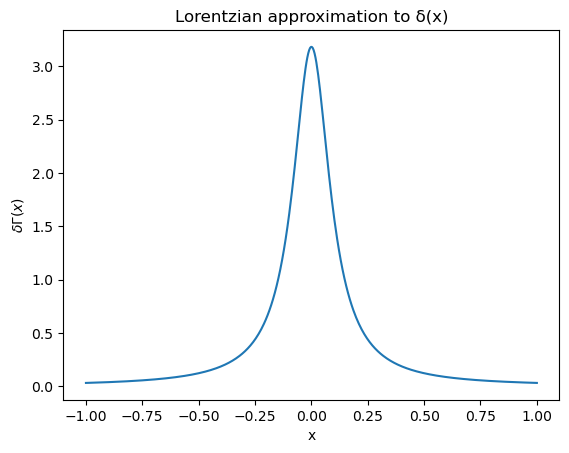

PyObject Text(0.5, 1.0, 'Lorentzian approximation to δ(x)')

In [6]:
Γ = 0.1
x = range(-1, 1, length=500)
y = [delta_fn(xi, Γ) for xi in x]

plot(x, y)
xlabel("x")
ylabel(L"$\delta \Gamma(x)$")
title("Lorentzian approximation to δ(x)")

In [30]:
"""
    fermi_fn(E, mu=0.0; beta=nothing, T=nothing)

Evaluate the Fermi-Dirac distribution using a numerically stable tanh form.

Arguments:
- `E`: energy value
- `mu`: chemical potential (default 0.0)
- `beta`: inverse temperature (1/T)
- `T`: temperature

Returns:
- Fermi-Dirac occupation value
"""
@inline function fermi_fn(E, mu=0.0; beta=nothing, T=nothing)

    if beta === nothing
        T === nothing && throw(ArgumentError("Provide either `beta` or `T`."))
        beta = inv(T)
    end

    x = beta * (E - mu)
    return 0.5 * (1 - tanh(0.5 * x))
end


"""
    fermi_fn_classic(E, T)

Evaluate the Fermi-Dirac distribution using the exponential form.

   Arguments:
- `E`: energy value
- `T`: temperature

    Returns:
- Fermi-Dirac occupation value
"""
@inline function fermi_fn_classic(E, T)
    x = E / T
    if x > 50
        return zero(x)
    elseif x < -50
        return one(x)
    else
        return inv(exp(x) + one(x))
    end
end


fermi_fn_classic

In [8]:
# Half filling at E = mu
@show fermi_fn(0.0; T=1.0)        # ~ 0.5

# Low temperature limit
@show fermi_fn(1.0; T=0.01)       # ~ 0.0
@show fermi_fn(-1.0; T=0.01)      # ~ 1.0

# Using beta explicitly
@show fermi_fn(0.5; beta=10.0)

# Classic vs tanh form (should agree)
@show fermi_fn(0.8; T=0.5)
@show fermi_fn_classic(0.8, 0.5)

fermi_fn(0.0; T = 1.0) = 0.5
fermi_fn(1.0; T = 0.01) = 0.0
fermi_fn(-1.0; T = 0.01) = 1.0
fermi_fn(0.5; beta = 10.0) = 0.006692850924284843
fermi_fn(0.8; T = 0.5) = 0.16798161486607555
fermi_fn_classic(0.8, 0.5) = 0.16798161486607552


0.16798161486607552

sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


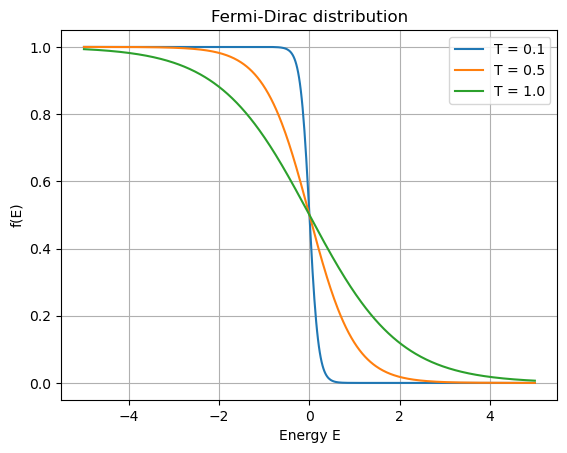

In [9]:
E = range(-5.0, 5.0, length=500)

Tvals = [0.1, 0.5, 1.0]

figure()
for T in Tvals
    f = [fermi_fn(e; T=T) for e in E]
    plot(E, f, label="T = $T")
end

xlabel("Energy E")
ylabel("f(E)")
title("Fermi-Dirac distribution")
legend()
grid(true)

show()

In [10]:
function fermi_fn_old(E::Float64, μ::Float64=0.0; kwargs...)::Float64
    if :β in keys(kwargs)
        β = kwargs[:β]
        return (1 - tanh(0.5 * β * (E - μ))) * 0.5
    elseif :beta in keys(kwargs)
        β = kwargs[:beta]
        return (1 - tanh(0.5 * β * (E - μ))) * 0.5
    elseif :T in keys(kwargs)
        T = kwargs[:T]
        return (1 - tanh(0.5 * (1 / T) * (E - μ))) * 0.5
    else
        throw(ArgumentError("Provide one of `β`, `beta`, or `T`."))
    end
end

fermi_fn_old (generic function with 2 methods)

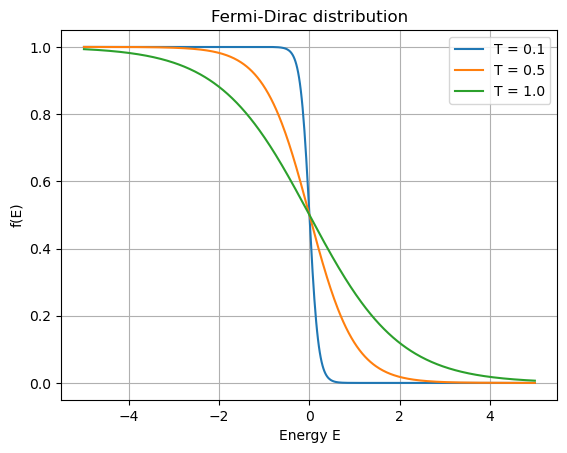

In [11]:
E = range(-5.0, 5.0, length=500)

Tvals = [0.1, 0.5, 1.0]

figure()
for T in Tvals
    f = [fermi_fn_old(e; T=T) for e in E]
    plot(E, f, label="T = $T")
end

xlabel("Energy E")
ylabel("f(E)")
title("Fermi-Dirac distribution")
legend()
grid(true)

show()

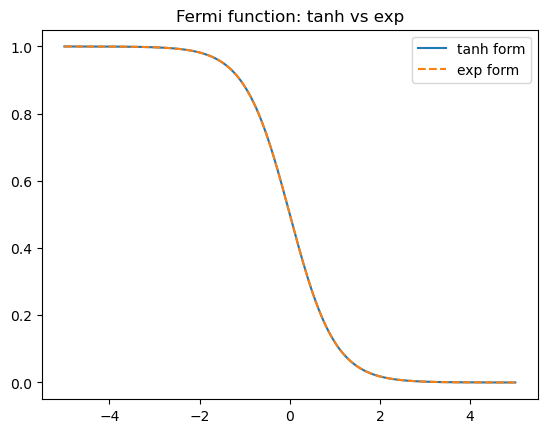

In [12]:
T = 0.5
f1 = [fermi_fn(e; T=T) for e in E]
f2 = [fermi_fn_classic(e, T) for e in E]

figure()
plot(E, f1, label="tanh form")
plot(E, f2, "--", label="exp form")
legend()
title("Fermi function: tanh vs exp")
show()

In [32]:
"""
    is_symmetric(A; tol=1e-10)

Check whether a real square matrix is symmetric within a tolerance.

Arguments:
- `A`: real square matrix
- `tol`: tolerance for symmetry check

Returns:
- `true` if max(abs(A - transpose(A))) < tol, otherwise `false`
"""
function is_symmetric(A::AbstractMatrix{<:Real}; tol::Real=1e-10)
    size(A, 1) == size(A, 2) ||
        throw(ArgumentError("Matrix must be square; got size=$(size(A))"))
    return maximum(abs.(A .- transpose(A))) < tol
end


"""
    is_hermitian(A; tol=1e-10)

Check whether a square matrix is Hermitian within a tolerance.

Arguments:
- `A`: real or complex square matrix
- `tol`: tolerance for Hermiticity check

Returns:
- `true` if max(abs(A - adjoint(A))) < tol, otherwise `false`
"""
function is_hermitian(A::AbstractMatrix{<:Number}; tol::Real=1e-10)
    size(A, 1) == size(A, 2) ||
        throw(ArgumentError("Matrix must be square; got size=$(size(A))"))
    return maximum(abs.(A .- adjoint(A))) < tol
end

is_hermitian

In [37]:
A = [1.0  2.0;
     2.0  3.0]

@show is_symmetric(A)

B = [1.0  2.0;
     3.0  4.0]

@show is_symmetric(B)

D = [1+0im  2+im;
     2-im   3+0im]

# is_symmetric(D)
# MethodError

is_symmetric(A) = true
is_symmetric(B) = false


2×2 Matrix{Complex{Int64}}:
 1+0im  2+1im
 2-1im  3+0im

In [38]:
A = [1.0  2.0;
     2.0  3.0]

@show is_hermitian(A)

H = [1+0im  2+im;
     2-im   3+0im]

@show is_hermitian(H)

S = [1+0im  2+im;
     2+im   3+0im]

@show is_hermitian(S)

is_hermitian(A) = true
is_hermitian(H) = true
is_hermitian(S) = false


false